In [1]:
import sqlite3

# Create SQLite DB file
conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()

# Create table
cursor.execute('''
CREATE TABLE IF NOT EXISTS sales (
    id INTEGER PRIMARY KEY,
    product TEXT,
    quantity INTEGER,
    price REAL
)
''')

# Insert sample data
sales_data = [
    ('Shirt', 10, 20.0),
    ('Pants', 5, 35.0),
    ('Shoes', 7, 50.0),
    ('Hat', 12, 10.0)
]

cursor.executemany("INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)", sales_data)
conn.commit()
conn.close()


  product  total_qty  revenue
0     Hat         12    120.0
1   Pants          5    175.0
2   Shirt         10    200.0
3   Shoes          7    350.0


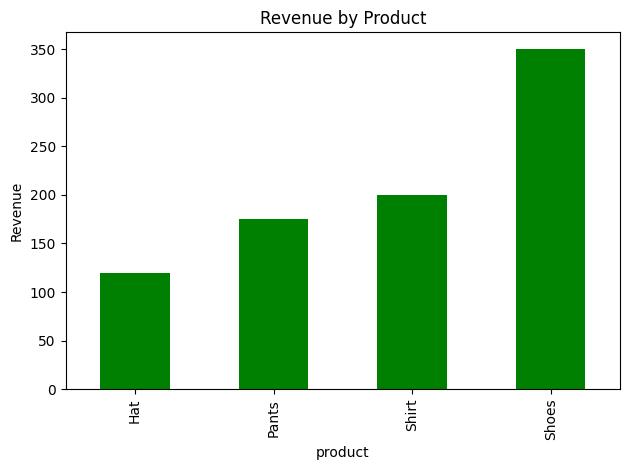

In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Reconnect to the DB
conn = sqlite3.connect("sales_data.db")

# SQL query
query = """
SELECT product,
       SUM(quantity) AS total_qty,
       SUM(quantity * price) AS revenue
FROM sales
GROUP BY product
"""

# Load into pandas
df = pd.read_sql_query(query, conn)
conn.close()

# Show results
print(df)

# Plot chart
df.plot(kind='bar', x='product', y='revenue', color='green', legend=False)
plt.title("Revenue by Product")
plt.ylabel("Revenue")
plt.tight_layout()
plt.savefig("sales_chart.png")  # Saves chart to your Colab files
plt.show()


In [3]:
from google.colab import files
files.download("sales_data.db")
files.download("sales_chart.png")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>